# CLIP CUB-200 Object-Aware Corruption + Decoy Prompt Probe

일반 ImageNet-C식 corruption 대신 CUB annotation을 이용해 새 자체, 배경, 머리/부리/날개 cue를 직접 건드립니다.

보는 것:
- **object-aware occlusion**: body/head/beak/wing 가리기
- **foreground/background split**: bird만 남김, background만 남김, bird/background blur
- **shape-destroying corruption**: severe downsample, patch shuffle, local pixelation, strong blur
- **semantic decoy prompt**: CUB 200 class 외에 `bird`, `sparrow`, `warbler`, `small brown bird` 같은 decoy가 prediction을 먹는지

In [1]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageDraw, ImageFilter

try:
    import open_clip
except ImportError as exc:
    raise ImportError("open_clip_torch가 필요합니다. repo root에서 `pip install -r requirements.txt` 실행 후 다시 시도하세요.") from exc

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data" / "cub200_prepared").exists():
    REPO_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(REPO_ROOT))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_ROOT = REPO_ROOT / "data" / "cub200_prepared"
METADATA_CSV = DATA_ROOT / "metadata.csv"

# 원본 CUB annotation. 다르면 여기만 바꾸면 됩니다.
CUB_ORIGINAL_ROOT = Path("/Users/taehayeong/Desktop/Git_workspace/Defect_Detection/data/CUB-200/CUB_200_2011")
PART_LOCS_TXT = CUB_ORIGINAL_ROOT / "parts" / "part_locs.txt"

SPLIT = "test"
N_SAMPLES = 64
SEED = 13

MODEL_NAME = "ViT-B-32"
PRETRAINED = "openai"
PROMPT_TEMPLATE = "a photo of a {}, a type of bird"

TOPK = 5
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

DEVICE

device(type='mps')

## 해석할 핵심 지표

- `cub_accuracy`: top-1이 CUB 200 class 중 정답 class인지
- `decoy_win_rate`: top-1이 CUB class가 아니라 decoy prompt인지
- `generic_decoy_win_rate`: `bird`, `small bird`, `brown bird` 같은 상위/일반 설명이 이긴 비율
- `fine_group_decoy_win_rate`: `sparrow`, `warbler`, `gull` 같은 class family decoy가 이긴 비율
- `true_prob`: 정답 class prompt에 할당된 softmax probability
- `cub_margin`: 정답 CUB class 점수 - 가장 강한 오답 CUB class 점수

In [3]:
def clean_label(class_name: str) -> str:
    name = class_name.split(".", 1)[1] if "." in class_name else class_name
    return name.replace("_", " ").lower()


meta = pd.read_csv(METADATA_CSV)
meta = meta[meta.split == SPLIT].copy()
meta["label"] = meta.class_name.map(clean_label)
meta["path"] = meta.relative_path.map(lambda p: DATA_ROOT / SPLIT / p)
meta = meta[meta.path.map(lambda p: Path(p).exists())].copy()

classes = [clean_label(x) for x in sorted(pd.read_csv(METADATA_CSV).class_name.unique())]
class_to_idx = {label: idx for idx, label in enumerate(classes)}

sample_df = meta.sample(n=min(N_SAMPLES, len(meta)), random_state=SEED).reset_index(drop=True)
print(f"classes: {len(classes)}")
print(f"available {SPLIT} images: {len(meta)}")
print(f"sampled: {len(sample_df)}")
sample_df[["image_id", "relative_path", "label", "bbox_x", "bbox_y", "bbox_width", "bbox_height"]].head()

classes: 200
available test images: 5794
sampled: 64


,image_id,relative_path,label,bbox_x,bbox_y,bbox_width,bbox_height
0,3851,067.Anna_Hummingbird/Anna_Hummingbird_0099_559...,anna hummingbird,128.0,8.0,231.0,322.0
1,8940,153.Philadelphia_Vireo/Philadelphia_Vireo_0028...,philadelphia vireo,73.0,83.0,365.0,158.0
2,883,016.Painted_Bunting/Painted_Bunting_0085_15282...,painted bunting,75.0,38.0,386.0,277.0
3,10642,181.Worm_eating_Warbler/Worm_Eating_Warbler_00...,worm eating warbler,35.0,107.0,333.0,200.0
4,10515,179.Tennessee_Warbler/Tennessee_Warbler_0065_1...,tennessee warbler,128.0,99.0,315.0,188.0


In [4]:
part_names = {
    1: "back", 2: "beak", 3: "belly", 4: "breast", 5: "crown", 6: "forehead", 7: "left eye",
    8: "left leg", 9: "left wing", 10: "nape", 11: "right eye", 12: "right leg", 13: "right wing",
    14: "tail", 15: "throat",
}

part_locs = pd.read_csv(PART_LOCS_TXT, sep=" ", names=["image_id", "part_id", "x", "y", "visible"])
part_locs["part_name"] = part_locs.part_id.map(part_names)
part_locs = part_locs[part_locs.visible == 1].copy()
print(f"visible part annotations: {len(part_locs)}")
part_locs.head()

visible part annotations: 141407


,image_id,part_id,x,y,visible,part_name
1,1,2,312.0,182.0,1,beak
4,1,5,186.0,45.0,1,crown
5,1,6,247.0,79.0,1,forehead
9,1,10,100.0,221.0,1,nape
10,1,11,183.0,101.0,1,right eye


In [5]:
def clamp_box(box, size):
    w, h = size
    x1, y1, x2, y2 = box
    return (max(0, int(x1)), max(0, int(y1)), min(w, int(x2)), min(h, int(y2)))


def bbox_from_row(row, pad=0.0, size=None):
    x, y, bw, bh = float(row.bbox_x), float(row.bbox_y), float(row.bbox_width), float(row.bbox_height)
    x1, y1, x2, y2 = x - bw * pad, y - bh * pad, x + bw * (1 + pad), y + bh * (1 + pad)
    return clamp_box((x1, y1, x2, y2), size) if size else (x1, y1, x2, y2)


def fill_box(image, box, fill=(128, 128, 128)):
    out = image.copy()
    ImageDraw.Draw(out).rectangle(box, fill=fill)
    return out


def foreground_only(image, box, fill=(128, 128, 128)):
    out = Image.new("RGB", image.size, fill)
    out.paste(image.crop(box), box)
    return out


def background_only(image, box, fill=(128, 128, 128)):
    return fill_box(image, box, fill=fill)


def blur_region(image, box, blur_inside=True, radius=10):
    blurred = image.filter(ImageFilter.GaussianBlur(radius=radius))
    if blur_inside:
        out = image.copy()
        out.paste(blurred.crop(box), box)
        return out
    out = blurred.copy()
    out.paste(image.crop(box), box)
    return out


def part_box(row, parts, scale=0.18, fallback="bbox"):
    visible = part_locs[(part_locs.image_id == int(row.image_id)) & (part_locs.part_name.isin(parts))]
    if len(visible) == 0:
        if fallback == "bbox":
            return bbox_from_row(row, pad=0.0, size=None)
        return None
    x1, y1 = visible.x.min(), visible.y.min()
    x2, y2 = visible.x.max(), visible.y.max()
    bw, bh = float(row.bbox_width), float(row.bbox_height)
    pad = max(18, scale * max(bw, bh))
    return (x1 - pad, y1 - pad, x2 + pad, y2 + pad)


def severe_downsample(image, scale=0.14):
    w, h = image.size
    small = image.resize((max(1, int(w * scale)), max(1, int(h * scale))), Image.BILINEAR)
    return small.resize((w, h), Image.NEAREST)


def local_pixelation(image, block=18):
    w, h = image.size
    small = image.resize((max(1, w // block), max(1, h // block)), Image.BILINEAR)
    return small.resize((w, h), Image.NEAREST)


def patch_shuffle(image, grid=4):
    w, h = image.size
    xs = np.linspace(0, w, grid + 1).astype(int)
    ys = np.linspace(0, h, grid + 1).astype(int)
    patches = []
    boxes = []
    for yi in range(grid):
        for xi in range(grid):
            box = (xs[xi], ys[yi], xs[xi + 1], ys[yi + 1])
            boxes.append(box)
            patches.append(image.crop(box))
    shuffled = patches[:]
    random.shuffle(shuffled)
    out = Image.new("RGB", image.size)
    for box, patch in zip(boxes, shuffled):
        out.paste(patch.resize((box[2] - box[0], box[3] - box[1])), box)
    return out


def apply_variant(image, row, variant):
    bbox = bbox_from_row(row, pad=0.03, size=image.size)
    if variant == "clean":
        return image
    if variant == "bird_crop":
        return image.crop(bbox).resize(image.size, Image.BILINEAR)
    if variant == "foreground_only":
        return foreground_only(image, bbox)
    if variant == "background_only":
        return background_only(image, bbox)
    if variant == "bird_blur":
        return blur_region(image, bbox, blur_inside=True, radius=12)
    if variant == "background_blur":
        return blur_region(image, bbox, blur_inside=False, radius=12)
    if variant == "body_occlude":
        return fill_box(image, bbox)
    if variant == "head_occlude":
        box = clamp_box(part_box(row, ["beak", "crown", "forehead", "left eye", "right eye", "nape", "throat"], scale=0.10), image.size)
        return fill_box(image, box)
    if variant == "beak_occlude":
        box = clamp_box(part_box(row, ["beak"], scale=0.08), image.size)
        return fill_box(image, box)
    if variant == "wing_occlude":
        box = clamp_box(part_box(row, ["left wing", "right wing", "back"], scale=0.12), image.size)
        return fill_box(image, box)
    if variant == "strong_blur":
        return image.filter(ImageFilter.GaussianBlur(radius=8))
    if variant == "severe_downsample":
        return severe_downsample(image)
    if variant == "local_pixelation":
        return local_pixelation(image)
    if variant == "patch_shuffle":
        return patch_shuffle(image)
    raise ValueError(variant)


VARIANTS = [
    "clean", "bird_crop", "foreground_only", "background_only", "bird_blur", "background_blur",
    "body_occlude", "head_occlude", "beak_occlude", "wing_occlude",
    "strong_blur", "severe_downsample", "local_pixelation", "patch_shuffle",
]

In [6]:
model, _, preprocess = open_clip.create_model_and_transforms(MODEL_NAME, pretrained=PRETRAINED, device=DEVICE)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)
model.eval()
print(f"Loaded {MODEL_NAME}/{PRETRAINED} on {DEVICE}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loaded ViT-B-32/openai on mps


In [7]:
GENERIC_DECOYS = [
    "bird", "small bird", "large bird", "brown bird", "black bird", "white bird", "colorful bird",
    "water bird", "songbird", "wild bird", "bird in a tree", "bird in the sky",
]
FINE_GROUP_DECOYS = [
    "sparrow", "warbler", "vireo", "gull", "tern", "crow", "blackbird", "flycatcher", "woodpecker",
    "hummingbird", "wren", "thrasher", "bunting", "cormorant", "loon", "auklet", "finch",
]
NON_BIRD_DECOYS = ["branch", "tree", "sky", "water", "grass", "nest", "leaf", "rock", "background"]

labels = classes + GENERIC_DECOYS + FINE_GROUP_DECOYS + NON_BIRD_DECOYS
label_type = (["cub"] * len(classes) + ["generic_decoy"] * len(GENERIC_DECOYS) +
              ["fine_group_decoy"] * len(FINE_GROUP_DECOYS) + ["non_bird_decoy"] * len(NON_BIRD_DECOYS))
label_type_by_idx = dict(enumerate(label_type))

prompts = [PROMPT_TEMPLATE.format(label) for label in labels]
with torch.no_grad():
    text_tokens = tokenizer(prompts).to(DEVICE)
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    text_features = text_features.detach().cpu()

print(f"CUB labels: {len(classes)}")
print(f"decoy labels: {len(labels) - len(classes)}")

CUB labels: 200
decoy labels: 38


In [8]:
def encode_images(images, batch_size=32):
    feats = []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            batch = torch.stack([preprocess(img) for img in images[start:start + batch_size]]).to(DEVICE)
            feat = model.encode_image(batch)
            feat = feat / feat.norm(dim=-1, keepdim=True)
            feats.append(feat.detach().cpu())
    return torch.cat(feats, dim=0)


rows = []
preview = {}

for variant in VARIANTS:
    images = []
    for _, row in sample_df.iterrows():
        image = Image.open(row.path).convert("RGB")
        images.append(apply_variant(image, row, variant))
    preview[variant] = images[:8]

    image_features = encode_images(images)
    logits = 100.0 * image_features @ text_features.T
    probs = logits.softmax(dim=-1)
    top_probs, top_indices = probs.max(dim=1)

    cub_probs = probs[:, :len(classes)]
    cub_top_probs, cub_top_indices = cub_probs.max(dim=1)

    for sample_id, row in sample_df.iterrows():
        true_idx = class_to_idx[row.label]
        top_idx = int(top_indices[sample_id])
        cub_pred_idx = int(cub_top_indices[sample_id])
        false_cub = cub_probs[sample_id].clone()
        false_cub[true_idx] = -float("inf")
        rows.append({
            "sample_id": int(sample_id),
            "image_id": int(row.image_id),
            "variant": variant,
            "true_label": row.label,
            "top1_label": labels[top_idx],
            "top1_type": label_type_by_idx[top_idx],
            "top1_confidence": float(top_probs[sample_id]),
            "cub_pred_label": classes[cub_pred_idx],
            "cub_confidence": float(cub_top_probs[sample_id]),
            "true_prob": float(probs[sample_id, true_idx]),
            "cub_margin": float(cub_probs[sample_id, true_idx] - false_cub.max()),
            "cub_correct": classes[cub_pred_idx] == row.label,
            "top1_is_true_cub": top_idx == true_idx,
        })

pred_df = pd.DataFrame(rows)
pred_df.head()

,sample_id,image_id,variant,true_label,top1_label,top1_type,top1_confidence,cub_pred_label,cub_confidence,true_prob,cub_margin,cub_correct,top1_is_true_cub
0,0,3851,clean,anna hummingbird,red cockaded woodpecker,cub,0.159114,red cockaded woodpecker,0.159114,0.102848,-0.056266,False,False
1,1,8940,clean,philadelphia vireo,kentucky warbler,cub,0.092815,kentucky warbler,0.092815,0.068001,-0.024813,False,False
2,2,883,clean,painted bunting,painted bunting,cub,0.742273,painted bunting,0.742273,0.742273,0.719426,True,True
3,3,10642,clean,worm eating warbler,swainson warbler,cub,0.382011,swainson warbler,0.382011,0.007129,-0.374882,False,False
4,4,10515,clean,tennessee warbler,kentucky warbler,cub,0.139584,kentucky warbler,0.139584,0.136388,-0.003196,False,False


## Variant별 정량 결과

`decoy_win_rate`가 높으면 CLIP이 fine-grained class 이름보다 일반/상위/배경 prompt로 빠진 것입니다.

In [9]:
summary = pred_df.groupby("variant").agg(
    cub_accuracy=("cub_correct", "mean"),
    top1_true_cub_rate=("top1_is_true_cub", "mean"),
    mean_top1_confidence=("top1_confidence", "mean"),
    mean_cub_confidence=("cub_confidence", "mean"),
    mean_true_prob=("true_prob", "mean"),
    mean_cub_margin=("cub_margin", "mean"),
).reset_index()

type_rates = pred_df.pivot_table(index="variant", columns="top1_type", values="sample_id", aggfunc="count", fill_value=0)
type_rates = type_rates.div(type_rates.sum(axis=1), axis=0).reset_index()
for col in ["cub", "generic_decoy", "fine_group_decoy", "non_bird_decoy"]:
    if col not in type_rates.columns:
        type_rates[col] = 0.0

summary = summary.merge(type_rates, on="variant")
summary = summary.rename(columns={
    "cub": "cub_top1_rate",
    "generic_decoy": "generic_decoy_win_rate",
    "fine_group_decoy": "fine_group_decoy_win_rate",
    "non_bird_decoy": "non_bird_decoy_win_rate",
})

clean_row = summary[summary.variant == "clean"].iloc[0]
summary["delta_cub_accuracy"] = summary.cub_accuracy - clean_row.cub_accuracy
summary["delta_true_prob"] = summary.mean_true_prob - clean_row.mean_true_prob
summary["delta_decoy_win"] = (summary.generic_decoy_win_rate + summary.fine_group_decoy_win_rate + summary.non_bird_decoy_win_rate) - (clean_row.generic_decoy_win_rate + clean_row.fine_group_decoy_win_rate + clean_row.non_bird_decoy_win_rate)

display(summary.sort_values("delta_cub_accuracy").style.format({
    "cub_accuracy": "{:.3f}", "top1_true_cub_rate": "{:.3f}", "mean_top1_confidence": "{:.3f}",
    "mean_cub_confidence": "{:.3f}", "mean_true_prob": "{:.3f}", "mean_cub_margin": "{:+.3f}",
    "cub_top1_rate": "{:.3f}", "generic_decoy_win_rate": "{:.3f}",
    "fine_group_decoy_win_rate": "{:.3f}", "non_bird_decoy_win_rate": "{:.3f}",
    "delta_cub_accuracy": "{:+.3f}", "delta_true_prob": "{:+.3f}", "delta_decoy_win": "{:+.3f}",
}))

,variant,cub_accuracy,top1_true_cub_rate,mean_top1_confidence,mean_cub_confidence,mean_true_prob,mean_cub_margin,cub_top1_rate,fine_group_decoy_win_rate,generic_decoy_win_rate,non_bird_decoy_win_rate,delta_cub_accuracy,delta_true_prob,delta_decoy_win
1,background_only,0.031,0.016,0.087,0.045,0.011,-0.034,0.469,0.016,0.000,0.516,-0.391,-0.257,+0.469
5,body_occlude,0.031,0.016,0.087,0.045,0.011,-0.034,0.469,0.016,0.000,0.516,-0.391,-0.257,+0.469
9,local_pixelation,0.078,0.016,0.147,0.048,0.015,-0.030,0.109,0.000,0.016,0.875,-0.344,-0.252,+0.828
12,strong_blur,0.141,0.109,0.135,0.115,0.059,-0.034,0.656,0.062,0.062,0.219,-0.281,-0.208,+0.281
3,bird_blur,0.156,0.062,0.117,0.076,0.039,-0.022,0.500,0.047,0.031,0.422,-0.266,-0.229,+0.438
11,severe_downsample,0.219,0.172,0.148,0.126,0.080,-0.012,0.594,0.109,0.047,0.250,-0.203,-0.187,+0.344
10,patch_shuffle,0.234,0.219,0.187,0.154,0.094,-0.015,0.688,0.047,0.016,0.250,-0.188,-0.173,+0.250
8,head_occlude,0.266,0.250,0.200,0.177,0.095,-0.040,0.734,0.047,0.016,0.203,-0.156,-0.173,+0.203
2,beak_occlude,0.297,0.266,0.267,0.257,0.174,+0.005,0.812,0.078,0.016,0.094,-0.125,-0.094,+0.125
13,wing_occlude,0.328,0.312,0.216,0.204,0.131,-0.003,0.797,0.047,0.000,0.156,-0.094,-0.136,+0.141


## 무엇을 가렸을 때 무너지나?

clean에서 맞았는데 variant에서 틀린 비율을 봅니다. 이 값이 큰 variant가 CLIP이 의존하던 cue를 건드린 것입니다.

In [10]:
clean = pred_df[pred_df.variant == "clean"][["sample_id", "cub_correct", "true_prob", "cub_confidence", "top1_type"]].rename(columns={
    "cub_correct": "clean_correct", "true_prob": "clean_true_prob", "cub_confidence": "clean_cub_confidence", "top1_type": "clean_top1_type"
})
paired = pred_df.merge(clean, on="sample_id")
paired = paired[paired.variant != "clean"].copy()
paired["correct_to_wrong"] = paired.clean_correct & (~paired.cub_correct)
paired["wrong_conf_increased"] = (~paired.cub_correct) & (paired.cub_confidence > paired.clean_cub_confidence)
paired["decoy_after_clean_cub"] = (paired.clean_top1_type == "cub") & (paired.top1_type != "cub")

breakdown = paired.groupby("variant").agg(
    correct_to_wrong_rate=("correct_to_wrong", "mean"),
    wrong_confidence_increased_rate=("wrong_conf_increased", "mean"),
    decoy_after_clean_cub_rate=("decoy_after_clean_cub", "mean"),
    mean_true_prob_drop=("true_prob", lambda s: float((s - paired.loc[s.index, "clean_true_prob"]).mean())),
).reset_index()

display(breakdown.sort_values("correct_to_wrong_rate", ascending=False).style.format({
    "correct_to_wrong_rate": "{:.3f}",
    "wrong_confidence_increased_rate": "{:.3f}",
    "decoy_after_clean_cub_rate": "{:.3f}",
    "mean_true_prob_drop": "{:+.3f}",
}))

,variant,correct_to_wrong_rate,wrong_confidence_increased_rate,decoy_after_clean_cub_rate,mean_true_prob_drop
1,background_only,0.422,0.000,0.484,-0.257
5,body_occlude,0.422,0.000,0.484,-0.257
8,local_pixelation,0.359,0.000,0.828,-0.252
3,bird_blur,0.297,0.000,0.438,-0.229
11,strong_blur,0.281,0.016,0.297,-0.208
9,patch_shuffle,0.266,0.078,0.250,-0.173
7,head_occlude,0.234,0.109,0.234,-0.173
10,severe_downsample,0.234,0.031,0.359,-0.187
2,beak_occlude,0.172,0.141,0.141,-0.094
12,wing_occlude,0.156,0.047,0.172,-0.136


## Decoy / hub winners

어떤 decoy 또는 class가 variant에서 자주 top-1이 되는지 확인합니다.

In [11]:
winner_counts = (
    pred_df.groupby(["variant", "top1_type", "top1_label"])
    .agg(count=("top1_label", "size"), mean_confidence=("top1_confidence", "mean"))
    .sort_values(["variant", "count", "mean_confidence"], ascending=[True, False, False])
    .reset_index()
)

display(winner_counts[winner_counts.variant.isin(["clean", "background_only", "body_occlude", "bird_crop", "patch_shuffle"])]
        .groupby("variant")
        .head(12)
        .style.format({"mean_confidence": "{:.3f}"}))

,variant,top1_type,top1_label,count,mean_confidence
50,background_only,non_bird_decoy,background,17,0.099
51,background_only,non_bird_decoy,grass,5,0.200
52,background_only,non_bird_decoy,water,5,0.135
53,background_only,non_bird_decoy,branch,5,0.105
54,background_only,cub,swainson warbler,3,0.049
55,background_only,cub,pine warbler,2,0.081
56,background_only,cub,brown pelican,2,0.067
57,background_only,cub,black billed cuckoo,2,0.018
58,background_only,cub,rufous hummingbird,1,0.149
59,background_only,cub,eared grebe,1,0.120


## Plots

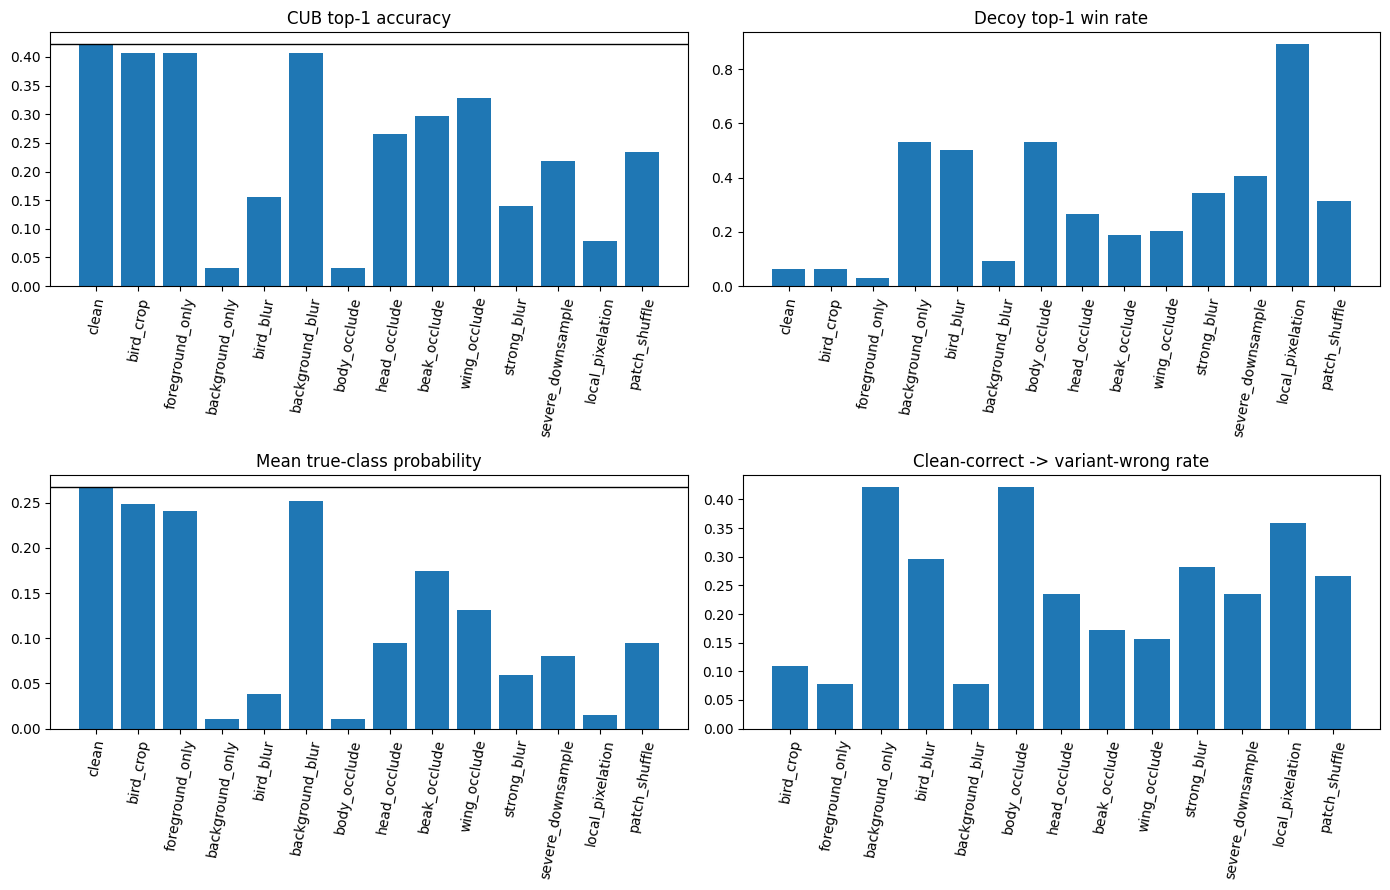

In [12]:
plot_df = summary.set_index("variant").loc[VARIANTS].reset_index()
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].bar(plot_df.variant, plot_df.cub_accuracy)
axes[0, 0].axhline(clean_row.cub_accuracy, color="black", linewidth=1)
axes[0, 0].set_title("CUB top-1 accuracy")
axes[0, 0].tick_params(axis="x", rotation=80)

decoy_total = plot_df.generic_decoy_win_rate + plot_df.fine_group_decoy_win_rate + plot_df.non_bird_decoy_win_rate
axes[0, 1].bar(plot_df.variant, decoy_total)
axes[0, 1].set_title("Decoy top-1 win rate")
axes[0, 1].tick_params(axis="x", rotation=80)

axes[1, 0].bar(plot_df.variant, plot_df.mean_true_prob)
axes[1, 0].axhline(clean_row.mean_true_prob, color="black", linewidth=1)
axes[1, 0].set_title("Mean true-class probability")
axes[1, 0].tick_params(axis="x", rotation=80)

bd = breakdown.set_index("variant").loc[[v for v in VARIANTS if v != "clean"]].reset_index()
axes[1, 1].bar(bd.variant, bd.correct_to_wrong_rate)
axes[1, 1].set_title("Clean-correct -> variant-wrong rate")
axes[1, 1].tick_params(axis="x", rotation=80)

plt.tight_layout()
plt.show()

## 이미지 preview

variant가 실제로 어떻게 생겼는지 확인합니다.

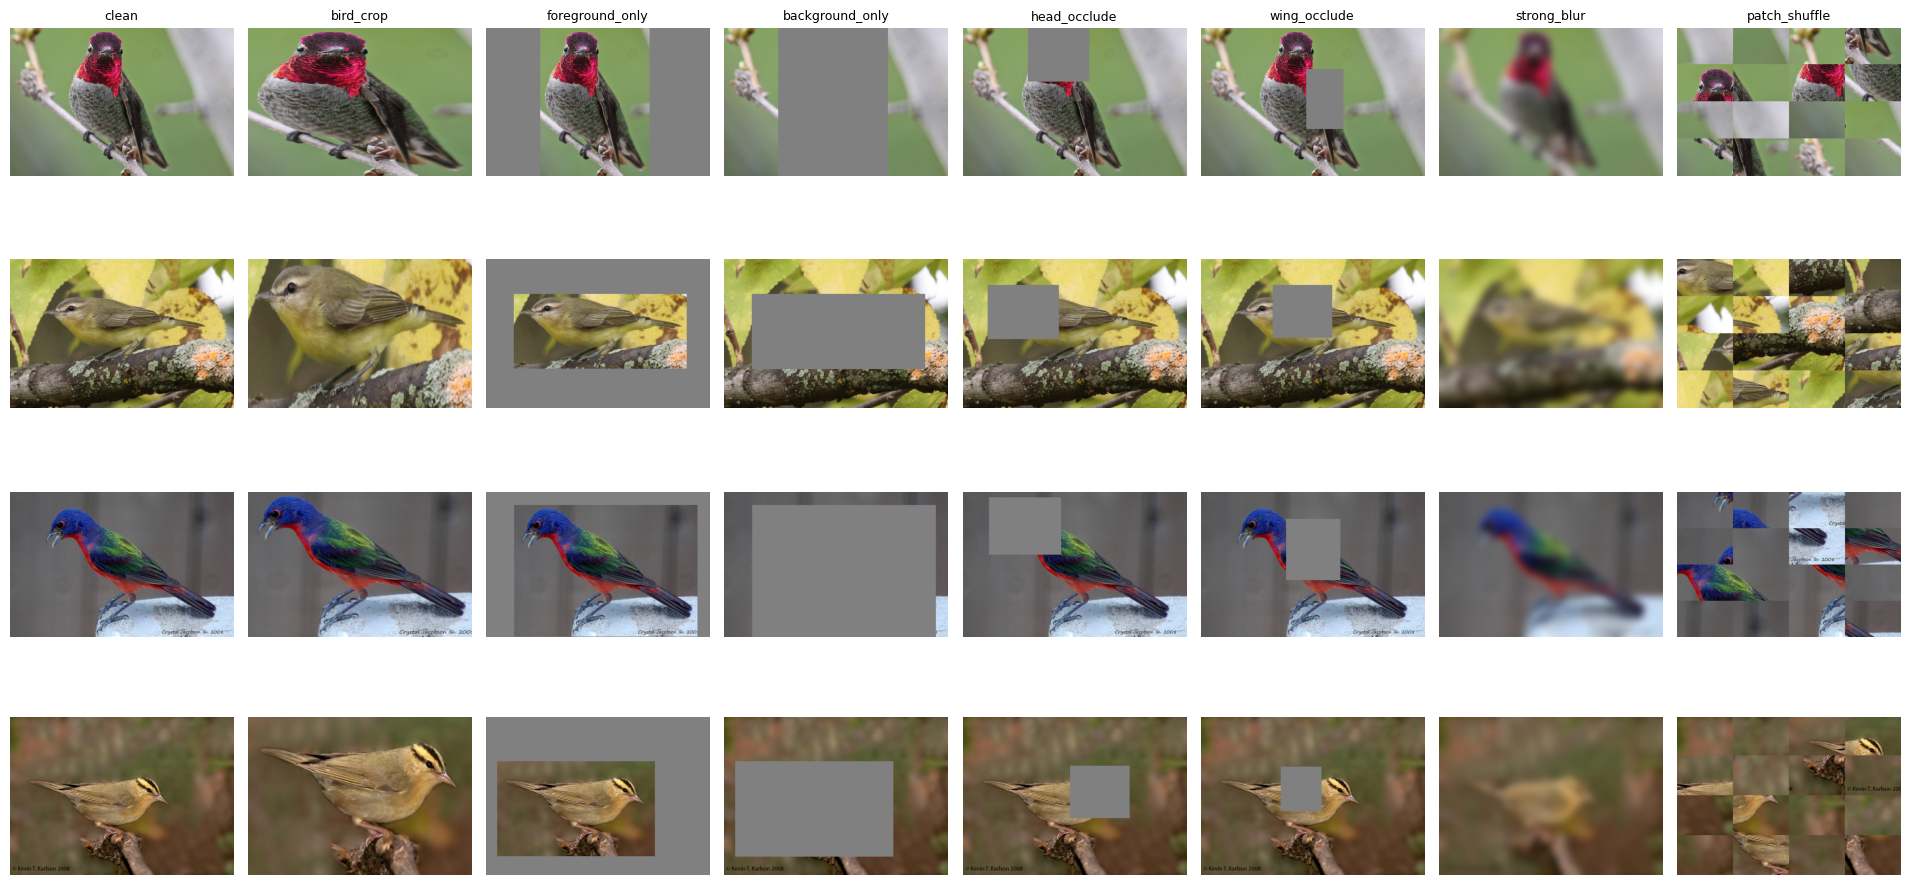

In [13]:
SHOW_VARIANTS = ["clean", "bird_crop", "foreground_only", "background_only", "head_occlude", "wing_occlude", "strong_blur", "patch_shuffle"]
n = min(4, len(sample_df))
fig, axes = plt.subplots(n, len(SHOW_VARIANTS), figsize=(2.4 * len(SHOW_VARIANTS), 2.5 * n))
if n == 1:
    axes = np.array([axes])

for r in range(n):
    for c, variant in enumerate(SHOW_VARIANTS):
        axes[r, c].imshow(preview[variant][r])
        title = variant if r == 0 else ""
        axes[r, c].set_title(title, fontsize=9)
        axes[r, c].axis("off")
plt.tight_layout()
plt.show()

## 샘플 하나 자세히 보기

clean에서는 맞았는데 object-aware variant에서 틀린 샘플을 자동으로 하나 골라 봅니다.

,variant,true_label,top1_label,top1_type,top1_confidence,cub_pred_label,cub_confidence,true_prob,cub_margin,cub_correct
0,clean,seaside sparrow,seaside sparrow,cub,0.182,seaside sparrow,0.182,0.182,+0.098,True
1,bird_crop,seaside sparrow,seaside sparrow,cub,0.081,seaside sparrow,0.081,0.081,+0.020,True
2,foreground_only,seaside sparrow,grass,non_bird_decoy,0.106,marsh wren,0.046,0.034,-0.012,False
3,background_only,seaside sparrow,grass,non_bird_decoy,0.180,marsh wren,0.073,0.022,-0.051,False
4,bird_blur,seaside sparrow,grass,non_bird_decoy,0.160,marsh wren,0.052,0.007,-0.045,False
5,background_blur,seaside sparrow,grass,non_bird_decoy,0.178,palm warbler,0.072,0.013,-0.060,False
6,body_occlude,seaside sparrow,grass,non_bird_decoy,0.180,marsh wren,0.073,0.022,-0.051,False
7,head_occlude,seaside sparrow,marsh wren,cub,0.478,marsh wren,0.478,0.028,-0.449,False
8,beak_occlude,seaside sparrow,marsh wren,cub,0.147,marsh wren,0.147,0.105,-0.043,False
9,wing_occlude,seaside sparrow,marsh wren,cub,0.166,marsh wren,0.166,0.018,-0.148,False


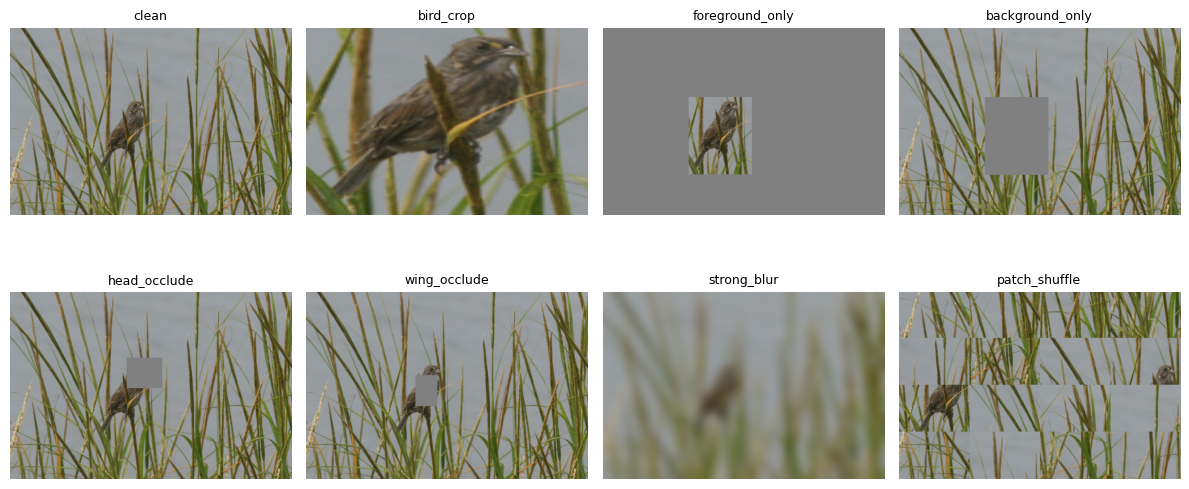

In [14]:
candidates = paired[paired.correct_to_wrong].sort_values(["variant", "true_prob"])
SAMPLE_ID_TO_INSPECT = int(candidates.iloc[0].sample_id) if len(candidates) else 0

inspect_df = pred_df[pred_df.sample_id == SAMPLE_ID_TO_INSPECT][[
    "variant", "true_label", "top1_label", "top1_type", "top1_confidence", "cub_pred_label", "cub_confidence", "true_prob", "cub_margin", "cub_correct"
]]
display(inspect_df.set_index("variant").loc[VARIANTS].reset_index().style.format({
    "top1_confidence": "{:.3f}", "cub_confidence": "{:.3f}", "true_prob": "{:.3f}", "cub_margin": "{:+.3f}",
}))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, variant in zip(axes.ravel(), SHOW_VARIANTS):
    ax.imshow(preview[variant][SAMPLE_ID_TO_INSPECT] if SAMPLE_ID_TO_INSPECT < len(preview[variant]) else apply_variant(Image.open(sample_df.loc[SAMPLE_ID_TO_INSPECT, 'path']).convert('RGB'), sample_df.loc[SAMPLE_ID_TO_INSPECT], variant))
    ax.set_title(variant, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()